## 1.Imports

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from qiskit.circuit.library import  efficient_su2, unitary_overlap
from qiskit.quantum_info import Statevector

import sys

sys.path.append(".\\..")
from src.metrics import get_scores, scores_structure, build_kernel
from src.preprocessing import unitary_preparation


## 2.Configuration

In [2]:
def  Efficient_SU2_kernel_value(x1, x2):
    """
        k(x1, x2) = |<psi(x1)|psi(x2)>|^2
    """
    circuit = efficient_su2(num_qubits=8, reps=1, insert_barriers=True)

    unitary1 = circuit.assign_parameters(x1)
    unitary2 = circuit.assign_parameters(x2)

    overlap_circuit = unitary_overlap(unitary1, unitary2)
    sv = Statevector(overlap_circuit)
    kernel_value = abs(sv.data[0]) ** 2

    return kernel_value

data = load_breast_cancer()
X = data.data
y = data.target

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)


## 3.Processing

In [3]:
quantum_scores = scores_structure.copy()
for train_idx, test_idx in skf.split(X, y):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    uX_train ,uX_test = unitary_preparation(X_train, X_test)
    
    
    # Quantum kernel
    kernel, test = build_kernel(uX_train, uX_test, Efficient_SU2_kernel_value)

    quantum = SVC(kernel="precomputed")
    quantum.fit(kernel, y_train)
    scores = get_scores(y_test, quantum.predict(test))
    for key in scores.keys():
        quantum_scores[key] += scores[key] / 5
    

print(quantum_scores)



{'accuracy': 0.9051855301971743, 'precision_malignant': 0.9333471842923062, 'recall_malignant': 0.8019933554817276, 'f1_malignant': 0.8613319406090489, 'precision_benign': 0.892952938283287, 'recall_benign': 0.9663536776212833, 'f1_benign': 0.9278748099940152, 'macro_f1': 0.8946033753015321, 'balanced_accuracy': 0.8841735165515053}


## Circuit Structure

8
32
ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7]), ParameterVectorElement(θ[8]), ParameterVectorElement(θ[9]), ParameterVectorElement(θ[10]), ParameterVectorElement(θ[11]), ParameterVectorElement(θ[12]), ParameterVectorElement(θ[13]), ParameterVectorElement(θ[14]), ParameterVectorElement(θ[15]), ParameterVectorElement(θ[16]), ParameterVectorElement(θ[17]), ParameterVectorElement(θ[18]), ParameterVectorElement(θ[19]), ParameterVectorElement(θ[20]), ParameterVectorElement(θ[21]), ParameterVectorElement(θ[22]), ParameterVectorElement(θ[23]), ParameterVectorElement(θ[24]), ParameterVectorElement(θ[25]), ParameterVectorElement(θ[26]), ParameterVectorElement(θ[27]), ParameterVectorElement(θ[28]), ParameterVectorElement(θ[29]), ParameterVectorElement(θ[30]), ParameterVectorElement(θ[31])

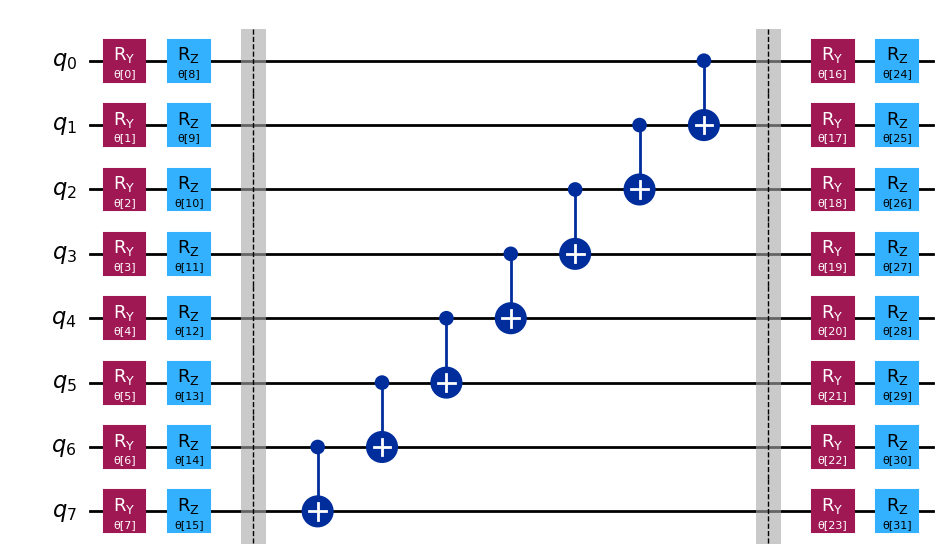

In [7]:
circuit = efficient_su2(num_qubits=8, reps=1, insert_barriers=True)
print(circuit.num_qubits)
print(circuit.num_parameters)
print(circuit.parameters)

circuit.draw("mpl")
